In this notebook we will use transfer learning and take pre-trained model from google's Tensorflow Hub and re-train that on flowers dataset. Using pre-trained model saves lot of time and computational budget for new classification problem at hand

In [1]:
import numpy as np
import cv2

import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import tf_keras


In [2]:
#Make predictions using ready made model (without any training)

IMAGE_SHAPE = (224, 224)

#mobilenet_v2
classifier = tf_keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
])

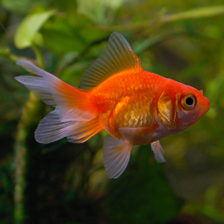

In [3]:
import PIL.Image as Image

gold_fish = Image.open("gold_fish.png").resize(IMAGE_SHAPE)
gold_fish

In [4]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

np.newaxis: This is a special constant from NumPy that is used to add a new axis (or dimension) to an array. It is equivalent to adding a dimension of size 1 at the specified position.

... (ellipsis): This is shorthand for "include all other dimensions as they are." It allows you to keep the remaining dimensions of the array unchanged.

Example:

Suppose gold_fish is an image array with shape (224, 224, 3), representing an RGB image (height, width, channels). This array has three dimensions:

224: Height of the image.

224: Width of the image.

3: Color channels (Red, Green, Blue).

By using gold_fish[np.newaxis, ...], you're adding a new dimension at the beginning, resulting in a 4D array. The new shape would be:

Before: (224, 224, 3)

After: (1, 224, 224, 3)

This new shape is common when preparing images for models, particularly convolutional neural networks (CNNs), where the input often needs to be in batches (even if it's a single image).

Why Use This?

Batch Dimension: When feeding an image into a neural network, the model typically expects the input to have a batch dimension, which represents the number of images in a batch. Even if you're working with a single image, you need to add this dimension. In this case, the new shape (1, 224, 224, 3) represents a "batch" containing one image.

Maintain Compatibility with Model Input: Many deep learning models expect a 4D input tensor with the shape (batch_size, height, width, channels). Using np.newaxis helps reshape a single image to meet this requirement.

In [5]:
gold_fish[np.newaxis, ...]

array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

In [6]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result.shape

1/1 [==============================] - 1s 1s/step


(1, 1001)

In [7]:
#The argmax() function is commonly used in NumPy and TensorFlow to find the index of the maximum value along a specified axis in an array or tensor

predicted_label_index = np.argmax(result)
predicted_label_index

2

In [8]:
image_labels = []
with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [9]:
image_labels[predicted_label_index]

'goldfish'

In [10]:
#Load flowers data.....same as we did we data_augmentation file

In [11]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [12]:
image_count = len(list(data_dir.glob('**/*.jpg')))
print(image_count)

3670


In [13]:
roses = list(data_dir.glob('**/roses/*'))
tulips = list(data_dir.glob('**/tulips/*'))

In [14]:
flowers_images_dict = {
    'roses': list(data_dir.glob('**/roses/*')),
    'daisy': list(data_dir.glob('**/daisy/*')),
    'dandelion': list(data_dir.glob('**/dandelion/*')),
    'sunflowers': list(data_dir.glob('**/sunflowers/*')),
    'tulips': list(data_dir.glob('**/tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}


In [15]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [16]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [17]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)  
        y.append(flowers_labels_dict[flower_name])

In [18]:
X = np.array(X)
y = np.array(y)

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [20]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [21]:
#Making prediction using pre-trained model on new flowers dataset


In [22]:

X[0].shape

(180, 180, 3)

In [23]:

IMAGE_SHAPE+(3,)

(224, 224, 3)

In [24]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

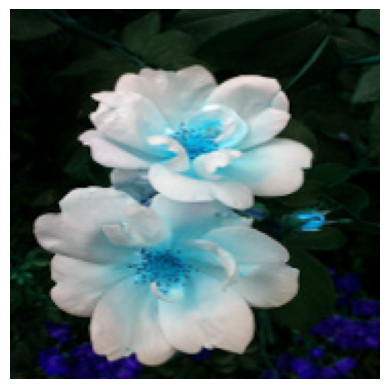

In [25]:
plt.axis('off')
plt.imshow(X[0])

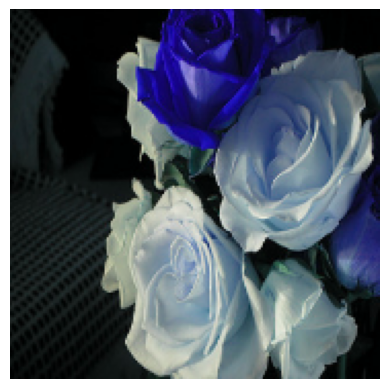

In [26]:
plt.axis('off')
plt.imshow(X[1])

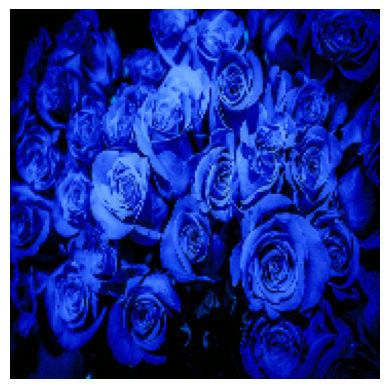

In [27]:
plt.axis('off')
plt.imshow(X[2])

In [28]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 [==============================] - 1s 1s/step


array([795, 795, 795], dtype=int64)

In [29]:
image_labels[795]

'shower curtain'

In [30]:
#Now take pre-trained model and retrain it using flowers images

In [31]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

#see the diff..."https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4" and "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
#here we are using feature_vector in our url...it means use same model as the previous one except the last layer.

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)    

#Note**: trainable=False....freeze....means do not train...while training all those layers will have fixed weights

In [32]:
num_of_flowers = 5

model = tf_keras.Sequential([
  pretrained_model_without_top_layer,
  tf_keras.layers.Dense(num_of_flowers)
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [33]:
X_train_scaled_resized = tf.image.resize(X_train_scaled, [224, 224])

In [34]:
model.compile(
  optimizer="adam",
  loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled_resized, y_train, epochs=5)

Epoch 1/5



86/86 [==============================] - 35s 356ms/step - loss: 0.7890 - acc: 0.7049
Epoch 2/5
86/86 [==============================] - 30s 344ms/step - loss: 0.4248 - acc: 0.8499
Epoch 3/5
86/86 [==============================] - 30s 346ms/step - loss: 0.3363 - acc: 0.8863
Epoch 4/5
86/86 [==============================] - 30s 346ms/step - loss: 0.2823 - acc: 0.9102
Epoch 5/5
86/86 [==============================] - 29s 338ms/step - loss: 0.2458 - acc: 0.9230


In [35]:
X_test_scaled_resized = tf.image.resize(X_test_scaled, [224, 224])

model.evaluate(X_test_scaled_resized,y_test)

29/29 [==============================] - 10s 322ms/step - loss: 0.3994 - acc: 0.8627


[0.39940884709358215, 0.8627451062202454]